In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Batch gradient descent
Batch : Each steps of gradient descent uses all the training examples

In [3]:
def compute_gradient(x, y, w, b):

    m = len(x) # total length of training dataset
    dj_dw = 0 # the gradient of cost j w.r.t. the parameter w
    dj_db = 0 # the gradient of cost j w.r.t. the parameter b
    
    for i in range(m):
        # predicted value
        f_wb_xi = w * x[i] + b # y_hat = f_wb_xi
        
        # calculate derivative term
        dj_dw_i = (f_wb_xi - y[i]) * x[i]
        dj_db_i = f_wb_xi - y[i]
        
        # addition derivative term
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    
    # divide by training examples
    dj_dw = (1 / m) * dj_dw
    dj_db = (1 / m) * dj_db
    
    # result
    return (dj_dw, dj_db)
    
# w = w - a * dj_dw
# b = b - a * dj_db
# a -> Learning rate 

# Scratch Linear Regression model

In [165]:
class LinearRegression:
    def __init__(self):
        # Initialization the parameters
        self.w = 0.0 # weight
        self.b = 0.0 # bias
    
    def fit(self, X, y, lr = 0.001, epochs=1000):
        # X -> features, y -> actual data, lr -> learning rate
        m = len(X)
        
        for epoch in range(epochs):
            # Initializing derivative of cost function w.r.t parameters w and b
            dw = 0.0
            db = 0.0
            
            # forward + gradient computation
            for i in range(m):
                # prediction
                y_hat = X[i] * self.w + self.b
                
                # Error and averaging gradients
                dw += (1 / m) * (y_hat - y[i]) * X[i]
                db += (1 / m) * (y_hat - y[i])
                
                # error = (y_hat - y[i])
                # dw += error * X[i]
                # db += error 
                
            # normalizing gradients
            # dw /= m
            # db /= m
            
            # parameters update
            self.w = self.w - lr * dw
            self.b = self.b - lr * db
        
        return self.w, self.b
    
    def predict(self, X):
        predications = []
        
        for x in X:
            y_hat = self.w * x + self.b
            predications.append(y_hat)
        
        return predications


In [77]:
# Load data from dataset
house_df = pd.read_csv('melb_data.csv.zip')
house_df.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [166]:
# feature names
feature_names = ['Lattitude', 'Longtitude', 'YearBuilt', 'Rooms',]

# DataFrame -> X
X = pd.Series(house_df['Rooms'])
X = X[:100]

# target values
y = house_df['Price']
y = y[:100]

model = LinearRegression()
model.fit(X, y)

y_hat = model.predict(X)
y_hat = np.asarray(y_hat)

# for i in range(len(y_hat)):
#     print(round(y_hat[i], 2))

m = len(X)
J = (1 / 2 * m) * np.sum((y_hat - y)**2)
print(J)

1416987244036297.0


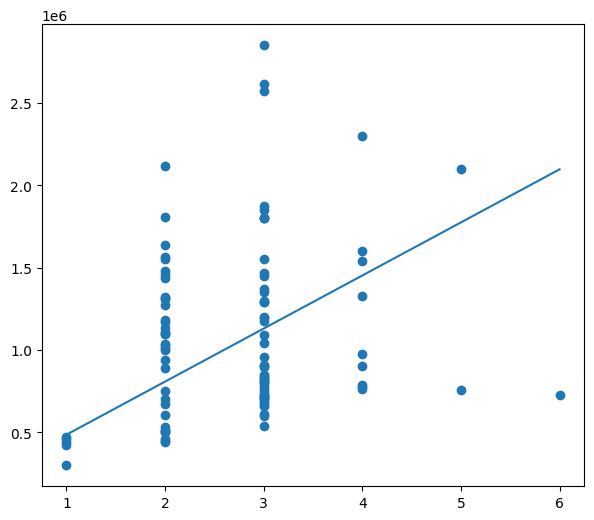

In [167]:
i = np.argsort(X)

X_sort = X[i]
y_sort = y[i]
y_hat = y_hat[i]

fig, ax = plt.subplots(figsize=(7,6))
# Actual data 
ax.scatter(X, y)

# predicated data
ax.plot(X_sort, y_hat)

plt.show()